<a href="https://colab.research.google.com/github/kady05naik/LeetCode/blob/main/2026_08_28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pyspark.sql import SparkSession
spark=SparkSession.builder.master('local').appName('myapp').getOrCreate()

**1.Write a solution to find the second highest distinct salary from the Employee table.**

If there is no second highest salary, return null
```
Example 1:
Employee table:
+----+--------+
| id | salary |
+----+--------+
| 1  | 100    |
| 2  | 200    |
| 3  | 300    |
+----+--------+
Output:
+---------------------+
| SecondHighestSalary |
+---------------------+
| 200                 |
+---------------------+
```



```
SELECT max(salary) AS SecondHighestSalary
FROM employee
WHERE salary < (SELECT MAX(salary) FROM employee);
```



In [2]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

data = [(1, 100), (2, 200), (3, 300)]
schema=("id Integer,salary Integer")
raw=spark.createDataFrame(data,schema)

WindowSpec=Window.orderBy(F.col('salary').desc())
df=raw.withColumn('rnk', F.dense_rank().over(WindowSpec))
df.select(F.col("salary").alias('SecondHighestSalary')).filter("rnk=2").show()

+-------------------+
|SecondHighestSalary|
+-------------------+
|                200|
+-------------------+



**2. Write a solution to find the nth highest distinct salary from the Employee table. If there are less than n distinct salaries, return null.**

The result format is in the following example.
```
Input:
Employee table:
+----+--------+
| id | salary |
+----+--------+
| 1  | 100    |
| 2  | 200    |
| 3  | 300    |
+----+--------+
n = 2
Output:
+------------------------+
| getNthHighestSalary(2) |
+------------------------+
| 200                    |
+------------------------+
```



```
CREATE FUNCTION getNthHighestSalary(N INT) RETURNS INT
BEGIN
  RETURN (
    SELECT Distinct salary
    FROM (
        SELECT
            id,
            salary,
            DENSE_RANK() OVER(ORDER BY salary DESC) AS rnk
        FROM
            employee
    )t
    WHERE rnk=n
 );
```



In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType
from pyspark.sql import functions as F
from pyspark.sql.window import Window

spark = SparkSession.builder.appName("EmployeeDataFrame").getOrCreate()

schema = StructType([
    StructField("Id", IntegerType(), True),
    StructField("Salary", IntegerType(), True)
])
data = [
    (1, 100),
    (2, 200),
    (3, 300)
]
employee_df = spark.createDataFrame(data, schema=schema)

windowSpec=Window.orderBy(F.col('salary').desc())
high_sal_df=employee_df.withColumn('rnk', F.dense_rank().over(windowSpec))
high_sal_df.select(F.col("salary").alias('highest_salary')).filter(F.col('rnk')==4).show()

+--------------+
|highest_salary|
+--------------+
+--------------+



**3. Write a solution to find the rank of the scores. The ranking should be
calculated according to the following rules:**

1. The scores should be ranked from the highest to the lowest.

2. If there is a tie between two scores, both should have the same ranking.

3. After a tie, the next ranking number should be the next consecutive integer value.

4. In other words, there should be no holes between ranks.

5. Return the result table ordered by score in descending order.

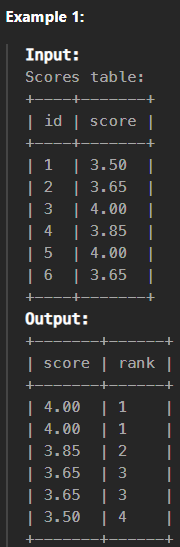



```
WITH cte_score AS
(
    SELECT
        score,
        DENSE_RANK() OVER(ORDER BY score desc) AS rnk   
    FROM scores
)
SELECT
    score,
    rnk AS 'rank'
FROM cte_score
ORDER BY rnk;
```



In [16]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

data = [
    (1, 3.5),
    (2, 3.65),
    (3, 4.0),
    (4,3.85),
    (5, 4.0),
    (6, 3.65)
]

scores_df = spark.createDataFrame(data, ['id', 'score'])

window_spec=Window.orderBy(F.col('score').desc())

score_rank_df=scores_df.withColumn('rank',F.dense_rank().over(window_spec))

score_rank_df.select(F.col('score'),
                     F.col('rank')).show()


+-----+----+
|score|rank|
+-----+----+
|  4.0|   1|
|  4.0|   1|
| 3.85|   2|
| 3.65|   3|
| 3.65|   3|
|  3.5|   4|
+-----+----+

